In [1]:
!pip install networkx torch torch-geometric scipy scikit-learn matplotlib

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_auc_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.utils import from_scipy_sparse_matrix, dense_to_sparse

Building Graph from ca-AstroPh.txt...
Graph loaded: 1103 nodes, 1458 edges.


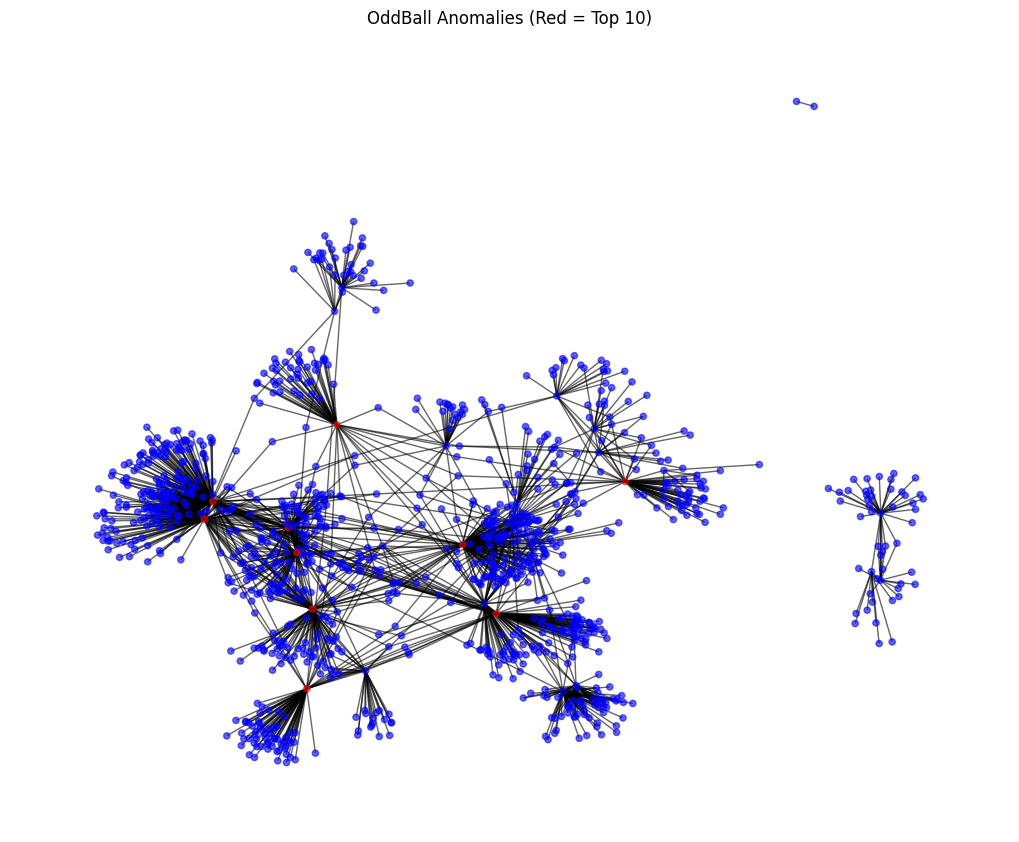

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


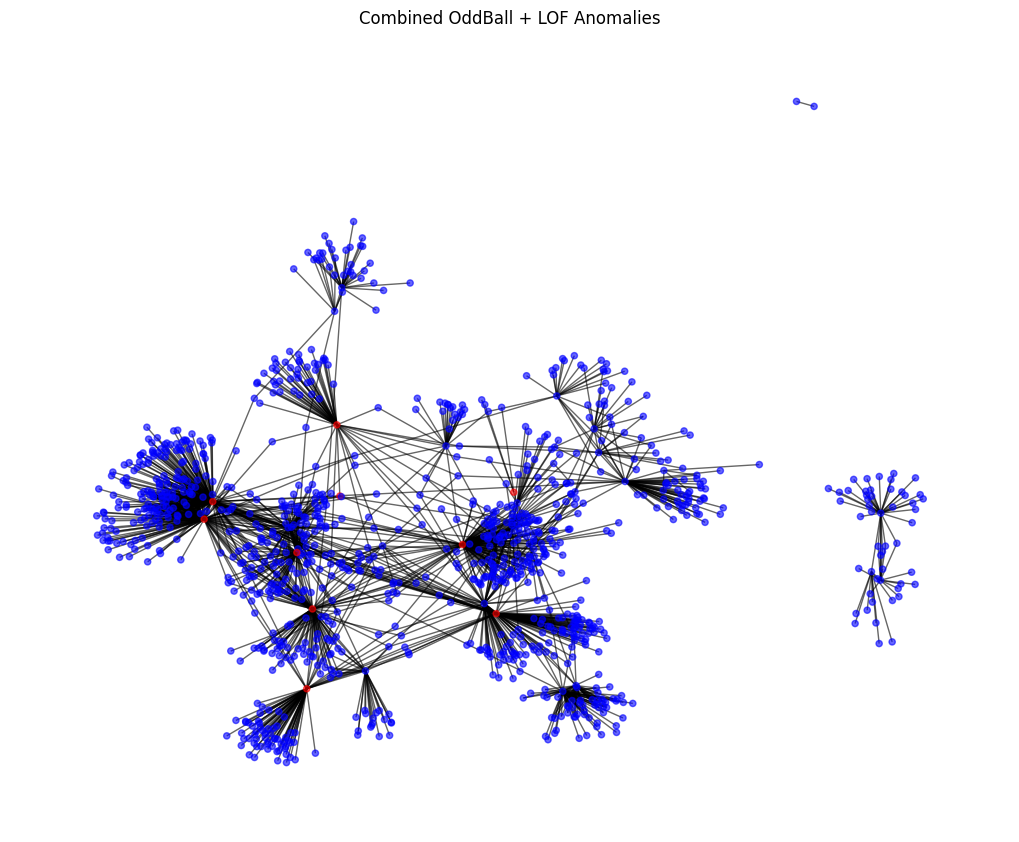

In [2]:
def extract_egonet_features(G, node):
    ego = nx.ego_graph(G, node, radius=1)

    Ni = ego.number_of_nodes()

    Ei = ego.number_of_edges()

    Wi = sum(d.get('weight', 1) for u, v, d in ego.edges(data=True))

    try:
        adj = nx.to_numpy_array(ego, weight='weight')
        eigenvalues = np.linalg.eigh(adj)[0]
        lambda_w = np.max(np.abs(eigenvalues)) if len(eigenvalues) > 0 else 0
    except:
        lambda_w = 0

    return Ni, Ei, Wi, lambda_w

print("Building Graph from ca-AstroPh.txt...")
G_astro = nx.Graph()
file_path = '/content/ca-AstroPh.txt'

with open(file_path, 'r') as f:
    lines = f.readlines()[:1500]
    for line in lines:
        if line.startswith('#'): continue
        parts = line.strip().split()
        if len(parts) < 2: continue
        u, v = parts[0], parts[1]

        if G_astro.has_edge(u, v):
            G_astro[u][v]['weight'] += 1
        else:
            G_astro.add_edge(u, v, weight=1)

print(f"Graph loaded: {G_astro.number_of_nodes()} nodes, {G_astro.number_of_edges()} edges.")

features = {}
nodes = list(G_astro.nodes())

for node in nodes:
    features[node] = extract_egonet_features(G_astro, node)

Ni_arr = np.array([f[0] for f in features.values()])
Ei_arr = np.array([f[1] for f in features.values()])

mask = (Ni_arr > 0) & (Ei_arr > 0)
clean_nodes = np.array(nodes)[mask]
X = np.log(Ni_arr[mask]).reshape(-1, 1)
y = np.log(Ei_arr[mask])

reg = LinearRegression().fit(X, y)
theta = reg.coef_[0]
log_C = reg.intercept_
C = np.exp(log_C)

scores = {}
for i, node in enumerate(clean_nodes):
    n_val = Ni_arr[mask][i]
    e_val = Ei_arr[mask][i]

    e_pred = C * (n_val ** theta)

    numerator = max(e_val, e_pred)
    denominator = min(e_val, e_pred) + 1e-9
    diff = abs(e_val - e_pred)

    score = (numerator / denominator) * np.log(diff + 1)
    scores[node] = score

sorted_nodes = sorted(scores, key=scores.get, reverse=True)
top_10 = set(sorted_nodes[:10])

colors = ['red' if node in top_10 else 'blue' for node in G_astro.nodes()]

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_astro, seed=42)
nx.draw(G_astro, pos, node_size=20, node_color=colors, alpha=0.6)
plt.title("OddBall Anomalies (Red = Top 10)")
plt.show()

data_lof = np.column_stack((Ei_arr[mask], Ni_arr[mask]))
lof = LocalOutlierFactor(n_neighbors=20)
lof_scores_raw = -lof.fit_predict(data_lof)
lof_scores = -lof.negative_outlier_factor_

obs_vals = np.array(list(scores.values()))
norm_oddball = (obs_vals - obs_vals.min()) / (obs_vals.max() - obs_vals.min())

norm_lof = (lof_scores - lof_scores.min()) / (lof_scores.max() - lof_scores.min())

combined_scores = {}
for i, node in enumerate(clean_nodes):
    combined_scores[node] = norm_oddball[i] + norm_lof[i]

sorted_combined = sorted(combined_scores, key=combined_scores.get, reverse=True)
top_10_combined = set(sorted_combined[:10])
colors_combined = ['red' if node in top_10_combined else 'blue' for node in G_astro.nodes()]

plt.figure(figsize=(10, 8))
nx.draw(G_astro, pos, node_size=20, node_color=colors_combined, alpha=0.6)
plt.title("Combined OddBall + LOF Anomalies")
plt.show()

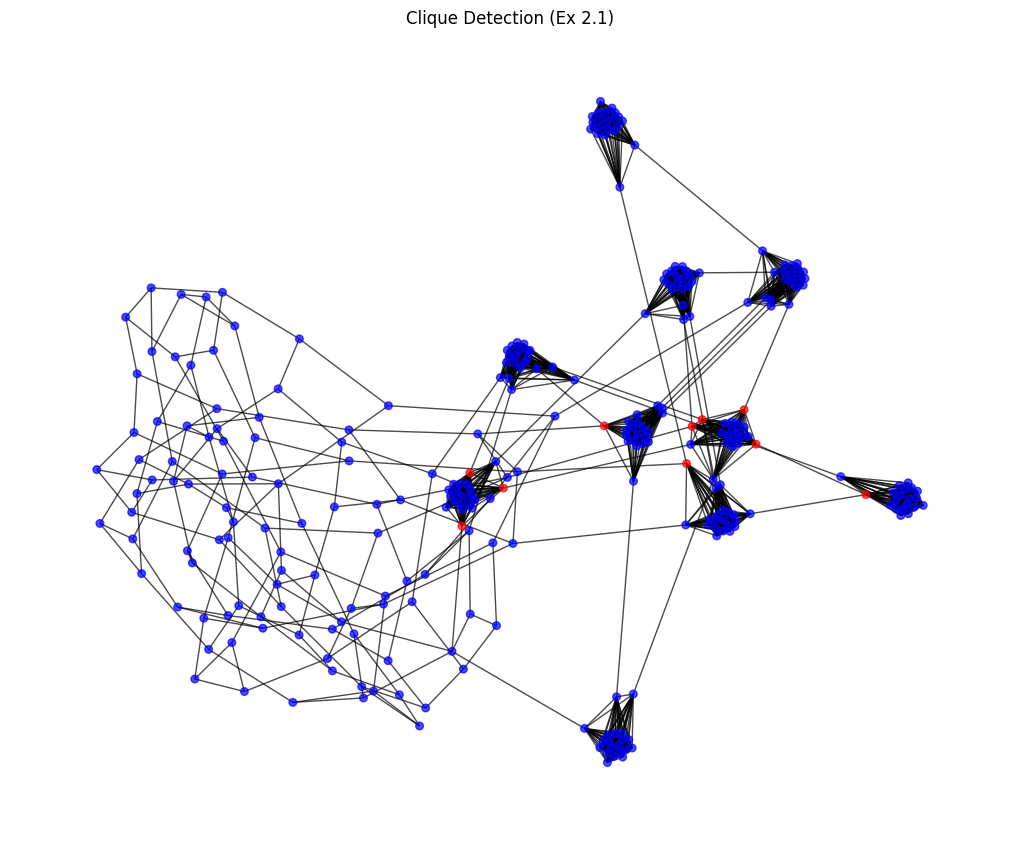

In [3]:
G_reg = nx.random_regular_graph(d=3, n=100, seed=42)

G_cave = nx.connected_caveman_graph(l=10, k=20)

G_merged = nx.union(G_reg, G_cave, rename=('R-', 'C-'))

nodes_list = list(G_merged.nodes())
import random
for _ in range(20):
    u = random.choice(nodes_list)
    v = random.choice(nodes_list)
    if u != v:
        G_merged.add_edge(u, v)

feat_clique = {}
for node in G_merged.nodes():
    feat_clique[node] = extract_egonet_features(G_merged, node)

Ni_c = np.array([f[0] for f in feat_clique.values()])
Ei_c = np.array([f[1] for f in feat_clique.values()])

mask_c = (Ni_c > 0) & (Ei_c > 0)
nodes_c_arr = np.array(list(G_merged.nodes()))[mask_c]

X_c = np.log(Ni_c[mask_c]).reshape(-1, 1)
y_c = np.log(Ei_c[mask_c])

reg_c = LinearRegression().fit(X_c, y_c)
theta_c = reg_c.coef_[0]
C_c = np.exp(reg_c.intercept_)

scores_c = {}
for i, node in enumerate(nodes_c_arr):
    n_val = Ni_c[mask_c][i]
    e_val = Ei_c[mask_c][i]
    e_pred = C_c * (n_val ** theta_c)

    num = max(e_val, e_pred)
    den = min(e_val, e_pred) + 1e-9
    scores_c[node] = (num/den) * np.log(abs(e_val - e_pred) + 1)

sorted_c = sorted(scores_c, key=scores_c.get, reverse=True)
top_10_c = set(sorted_c[:10])

colors_c = ['red' if node in top_10_c else 'blue' for node in G_merged.nodes()]
plt.figure(figsize=(10, 8))
nx.draw(G_merged, node_size=30, node_color=colors_c, alpha=0.7)
plt.title("Clique Detection (Ex 2.1)")
plt.show()

Injecting heavy vicinity anomalies at: ['A-19', 'A-80']
Detected Top 4: {np.str_('A-19'), np.str_('A-0'), np.str_('A-38'), np.str_('A-80')}


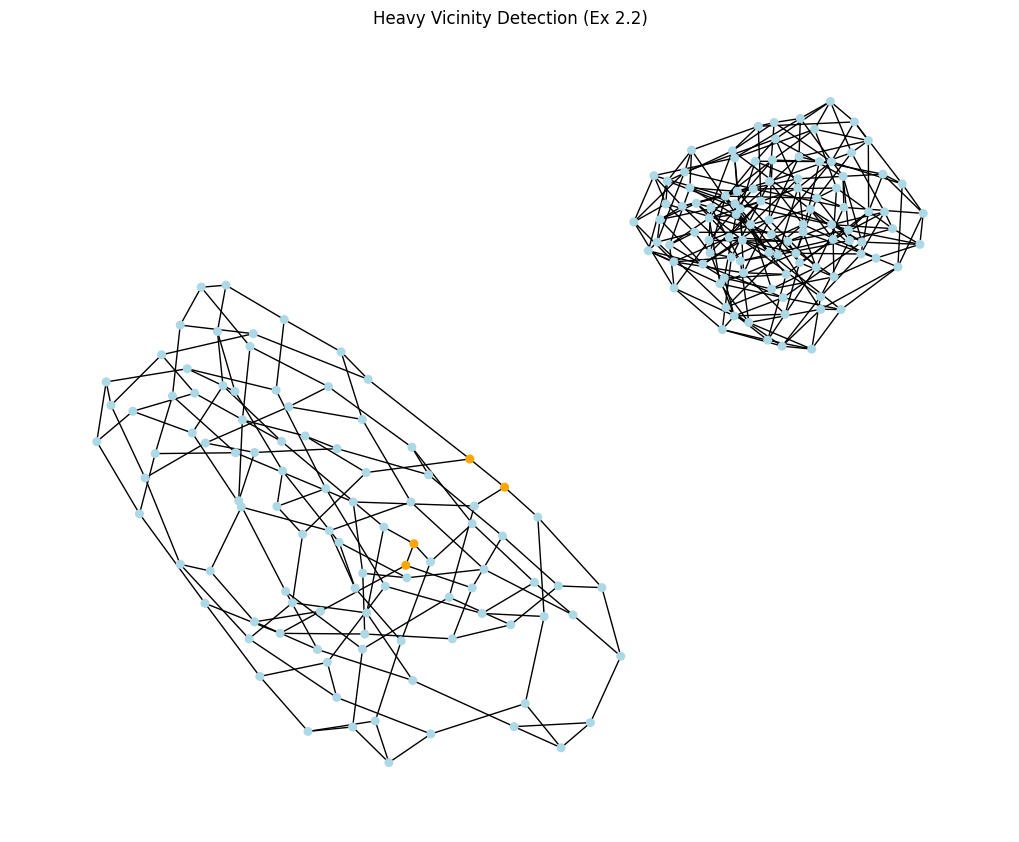

In [4]:
G1 = nx.random_regular_graph(d=3, n=100, seed=10)
G2 = nx.random_regular_graph(d=5, n=100, seed=20)

G_heavy = nx.union(G1, G2, rename=('A-', 'B-'))

for u, v in G_heavy.edges():
    G_heavy[u][v]['weight'] = 1.0

random_nodes = random.sample(list(G_heavy.nodes()), 2)
print(f"Injecting heavy vicinity anomalies at: {random_nodes}")

for center in random_nodes:
    ego = nx.ego_graph(G_heavy, center, radius=1)
    for u, v in ego.edges():
        if G_heavy.has_edge(u, v):
            G_heavy[u][v]['weight'] += 10.0

feat_heavy = {}
for node in G_heavy.nodes():
    feat_heavy[node] = extract_egonet_features(G_heavy, node)

Ei_h = np.array([f[1] for f in feat_heavy.values()])
Wi_h = np.array([f[2] for f in feat_heavy.values()])

mask_h = (Ei_h > 0) & (Wi_h > 0)
nodes_h_arr = np.array(list(G_heavy.nodes()))[mask_h]

X_h = np.log(Ei_h[mask_h]).reshape(-1, 1)
y_h = np.log(Wi_h[mask_h])

reg_h = LinearRegression().fit(X_h, y_h)
theta_h = reg_h.coef_[0]
C_h = np.exp(reg_h.intercept_)

scores_h = {}
for i, node in enumerate(nodes_h_arr):
    e_val = Ei_h[mask_h][i]
    w_val = Wi_h[mask_h][i]
    w_pred = C_h * (e_val ** theta_h)

    num = max(w_val, w_pred)
    den = min(w_val, w_pred) + 1e-9
    scores_h[node] = (num/den) * np.log(abs(w_val - w_pred) + 1)

sorted_h = sorted(scores_h, key=scores_h.get, reverse=True)
top_4_h = set(sorted_h[:4])
print("Detected Top 4:", top_4_h)

colors_h = ['orange' if node in top_4_h else 'lightblue' for node in G_heavy.nodes()]
plt.figure(figsize=(10, 8))
nx.draw(G_heavy, node_size=30, node_color=colors_h)
plt.title("Heavy Vicinity Detection (Ex 2.2)")
plt.show()

In [ ]:
mat = scipy.io.loadmat('/content/ACM.mat')
X_np = mat['Attributes']
A_sparse = mat['Network']
labels = mat['Label'].flatten()

X_tensor = torch.FloatTensor(X_np.toarray())
edge_index, _ = from_scipy_sparse_matrix(A_sparse)

A_dense = torch.FloatTensor(A_sparse.toarray())

class GraphAutoEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim1=128, hidden_dim2=64):
        super(GraphAutoEncoder, self).__init__()

        self.enc1 = GCNConv(input_dim, hidden_dim1)
        self.enc2 = GCNConv(hidden_dim1, hidden_dim2)

        self.attr_dec1 = GCNConv(hidden_dim2, hidden_dim1)
        self.attr_dec2 = GCNConv(hidden_dim1, input_dim)

        self.struct_dec1 = GCNConv(hidden_dim2, hidden_dim2)

    def forward(self, x, edge_index):
        z = F.relu(self.enc1(x, edge_index))
        z = F.relu(self.enc2(z, edge_index))

        x_hat = F.relu(self.attr_dec1(z, edge_index))
        x_hat = self.attr_dec2(x_hat, edge_index)

        z_struct = F.relu(self.struct_dec1(z, edge_index))
        a_hat = torch.matmul(z_struct, z_struct.t())

        return x_hat, a_hat

alpha = 0.8
lr = 0.004
epochs = 50

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GraphAutoEncoder(input_dim=X_tensor.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

X_tensor = X_tensor.to(device)
edge_index = edge_index.to(device)
A_dense = A_dense.to(device)

def custom_loss(X, X_hat, A, A_hat, alpha=0.8):
    attr_loss = torch.norm(X - X_hat, p='fro') ** 2
    struct_loss = torch.norm(A - A_hat, p='fro') ** 2
    return alpha * attr_loss + (1 - alpha) * struct_loss

print("Starting GAE Training...")
model.train()

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    X_rec, A_rec = model(X_tensor, edge_index)

    loss = custom_loss(X_tensor, X_rec, A_dense, A_rec, alpha)

    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        model.eval()
        with torch.no_grad():

            diff_attr = (X_tensor - X_rec) ** 2
            attr_error = torch.sum(diff_attr, dim=1)

            diff_struct = (A_dense - A_rec) ** 2
            struct_error = torch.sum(diff_struct, dim=1)

            total_error = alpha * attr_error + (1 - alpha) * struct_error
            scores = total_error.cpu().numpy()

            try:
                auc = roc_auc_score(labels, scores)
                print(f"Epoch {epoch} | Loss: {loss.item():.4f} | ROC AUC: {auc:.4f}")
            except ValueError:
                print(f"Epoch {epoch} | Loss: {loss.item():.4f} | (Error calculating AUC)")
        model.train()

print("Training finished.")

Starting GAE Training...
